# Notebook 01 — Corpus & Pair Generation (Stages 1–4)

Analyses the Ubuntu IRC Dialogue Corpus pipeline artifacts from Stage 1 (raw corpus), Stage 2 (cleaning), Stage 3 (temporal split), and Stage 4 (context-response pair generation).

| Section | Topic |
|---------|-------|
| **Stage 1** | Corpus loading, dialogue structure, length distribution |
| **Stage 2** | Cleaning stats, discard reasons, clean dialogue samples |
| **Stage 3** | Temporal split sizes and cutoff dates |
| **Stage 4** | Context-response pair counts, length distributions, domain filter |
| **Summary** | End-to-end stats panel |


In [1]:
# === SETUP: Imports, Paths, and Helpers ===

import json
import math
import os
import pickle
import random
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich import box

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
VIZ_DIR      = PROJECT_ROOT / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Stage artifact paths
STAGE1_PKL        = ARTIFACT_DIR / 'stage1_dialogues.pkl'
STAGE1_HASH       = ARTIFACT_DIR / '.stage1_config_hash'
STAGE2_PKL        = ARTIFACT_DIR / 'stage2_clean_dialogues.pkl'
STAGE2_STATS      = ARTIFACT_DIR / 'stage2_stats.json'
STAGE3_STATS      = ARTIFACT_DIR / 'stage3_stats.json'
STAGE3_TRAIN      = ARTIFACT_DIR / 'stage3_train.pkl'
STAGE3_VAL        = ARTIFACT_DIR / 'stage3_val.pkl'
STAGE3_TEST       = ARTIFACT_DIR / 'stage3_test.pkl'
STAGE4_TRAIN      = ARTIFACT_DIR / 'stage4_train_pairs.json'
STAGE4_VAL        = ARTIFACT_DIR / 'stage4_val_pairs.json'
STAGE4_TEST       = ARTIFACT_DIR / 'stage4_test_pairs.json'
STAGE4_STATS      = ARTIFACT_DIR / 'stage4_stats.json'
STAGE4_5_STATS    = ARTIFACT_DIR / 'stage4_5_filter_stats.json'
STAGE4_5_TRAIN    = ARTIFACT_DIR / 'stage4_5_train_pairs.json'

# ── Matplotlib defaults ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('muted')

console = Console(highlight=True)
random.seed(42)

# ── Helpers ───────────────────────────────────────────────────────────────
def _require(path: Path, label: str = '') -> bool:
    if path.exists():
        return True
    console.print(Panel(
        f'[bold red]File not found:[/bold red] {path}\n'
        f'[yellow]Run phase1.py to generate [italic]{label or path.name}[/italic].[/yellow]',
        title='⚠  Missing Artefact', border_style='red'
    ))
    return False

def _load_json(path: Path) -> dict:
    with open(path, encoding='utf-8') as f:
        return json.load(f)

def _load_jsonl(path: Path, max_lines: int = None) -> list:
    records = []
    with open(path, encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_lines and i >= max_lines:
                break
            records.append(json.loads(line))
    return records

def _save_fig(fig, name: str):
    out = VIZ_DIR / f'{name}.png'
    fig.savefig(out, bbox_inches='tight', dpi=150)
    console.print(f'[green]Saved[/green] → {out}')

console.print(Panel('[bold green]Setup complete[/bold green]\n'
    f'PROJECT_ROOT = {PROJECT_ROOT}\n'
    f'ARTIFACT_DIR = {ARTIFACT_DIR}',
    title='Notebook 01 — Corpus & Pair Generation', border_style='green'))


╭──────────────────────────────────── Notebook 01 — Corpus & Pair Generation ─────────────────────────────────────╮
│ Setup complete                                                                                                  │
│ PROJECT_ROOT = C:\git\nlp-final-project                                                                         │
│ ARTIFACT_DIR = C:\git\nlp-final-project\artifacts                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Stage 1 — Corpus Loading

In [2]:
# === SECTION S1.1: Load stage1_dialogues.pkl — basic stats ===

if not _require(STAGE1_PKL, 'stage1_dialogues.pkl'):
    raise SystemExit('Missing stage1 artifact')

with open(STAGE1_PKL, 'rb') as f:
    dialogues = pickle.load(f)

n_dialogues = len(dialogues)

# Inspect first dialogue to understand structure
first = dialogues[0]
console.print(f'[bold]Loaded[/bold] {n_dialogues:,} raw dialogues')
console.print(f'Type of dialogues: {type(dialogues)}')
console.print(f'Type of first item: {type(first)}')

# Determine turn structure
if isinstance(first, dict):
    console.print(f'First dialogue keys: {list(first.keys())}')
    turns = first.get('turns', first.get('utterances', [first]))
elif isinstance(first, (list, tuple)):
    turns = first
else:
    turns = [first]

t = Table(title='Stage 1 — Corpus Overview', box=box.ROUNDED, show_header=True)
t.add_column('Metric', style='cyan')
t.add_column('Value', style='white', justify='right')
t.add_row('Total raw dialogues', f'{n_dialogues:,}')
t.add_row('Example turns in first dialogue', str(len(turns)))
t.add_row('Artifact path', str(STAGE1_PKL))
console.print(t)

# Show example first dialogue
console.print(Panel(
    f'[bold]First dialogue (first 3 turns):[/bold]\n'
    + '\n'.join(f'  [{i}] {str(turn)[:120]}' for i, turn in enumerate(list(turns)[:3])),
    title='Example Dialogue Structure', border_style='blue'
))


Loaded 1,852,868 raw dialogues

Type of dialogues: <class 'list'>

Type of first item: <class 'dict'>

First dialogue keys: ['id', 'turns']

                                  Stage 1 — Corpus Overview                                  
╭─────────────────────────────────┬─────────────────────────────────────────────────────────╮
│ Metric                          │                                                   Value │
├─────────────────────────────────┼─────────────────────────────────────────────────────────┤
│ Total raw dialogues             │                                               1,852,868 │
│ Example turns in first dialogue │                                                     301 │
│ Artifact path                   │ C:\git\nlp-final-project\artifacts\stage1_dialogues.pkl │
╰─────────────────────────────────┴─────────────────────────────────────────────────────────╯

╭────────────────────────────────────────── Example Dialogue Structure ───────────────────────────────────────────╮
│ First dialogue (first 3 turns):                                                                                 │
│   [0] {'date': '2004-11-23T11:49:00.000Z', 'from': 'stuNNed', 'text': 'any ideas why java plugin takes so long  │
│ to load?'}                                                                                                      │
│   [1] {'date': '2004-11-23T11:49:00.000Z', 'from': 'crimsun', 'text': 'java 1.4?'}                              │
│   [2] {'date': '2004-11-23T11:49:00.000Z', 'from': 'stuNNed', 'text': 'yes'}                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [3]:
# === SECTION S1.2: Config hash stamp ===

if _require(STAGE1_HASH, '.stage1_config_hash'):
    hash_val = STAGE1_HASH.read_text().strip()
    console.print(Panel(
        f'[bold cyan].stage1_config_hash[/bold cyan]\n{hash_val}',
        title='Stage 1 Config Hash Stamp', border_style='cyan'
    ))
else:
    console.print('[yellow]No stage1 config hash found[/yellow]')


╭─────────────────────────────────────────── Stage 1 Config Hash Stamp ───────────────────────────────────────────╮
│ .stage1_config_hash                                                                                             │
│ 98a2e434b0c5                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

  Turns-per-Dialogue  
      Statistics      
                      
                      
 ━━━━━━━━━━━━━━━━━━━━ 
  Count    1,852,868  
  Min      1          
  Max      958        
  Mean     8.95       
  Median   6.0        
  Std      10.39      
  p95      24         
  p99      49

Saved → C:\git\nlp-final-project\notebooks\visualizations\s1_dialogue_length_dist.png

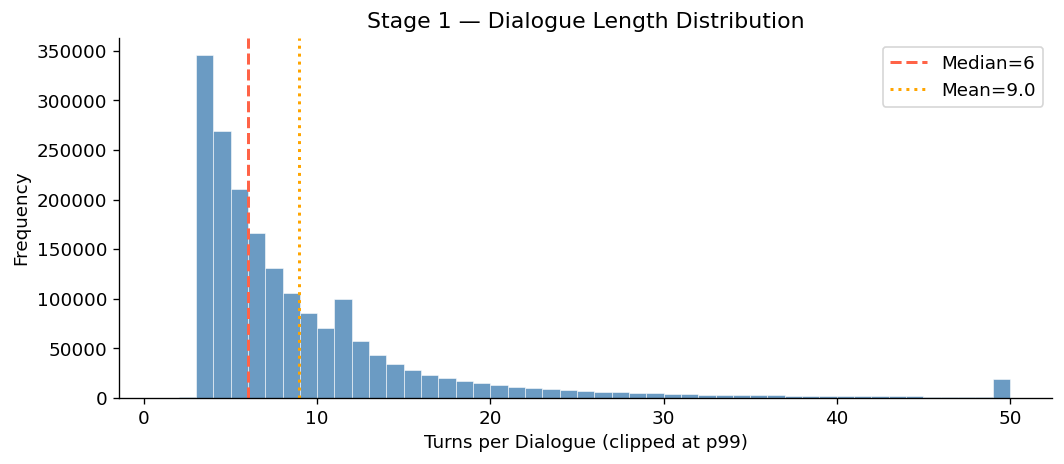

In [4]:
# === SECTION S1.3: Dialogue length distribution — turns per dialogue ===

def _get_turns(d):
    if isinstance(d, dict):
        for key in ('turns', 'utterances', 'messages', 'dialogue'):
            if key in d:
                return d[key]
        # fallback: count values if all values are lists
        vals = list(d.values())
        if vals and isinstance(vals[0], list):
            return vals[0]
        return list(d.values())
    elif isinstance(d, (list, tuple)):
        return d
    return [d]

turn_lengths = [len(_get_turns(d)) for d in dialogues]
tl = np.array(turn_lengths)

t = Table(title='Turns-per-Dialogue Statistics', box=box.SIMPLE_HEAVY)
for metric, val in [
    ('Count', f'{len(tl):,}'),
    ('Min', f'{tl.min()}'),
    ('Max', f'{tl.max()}'),
    ('Mean', f'{tl.mean():.2f}'),
    ('Median', f'{np.median(tl):.1f}'),
    ('Std', f'{tl.std():.2f}'),
    ('p95', f'{np.percentile(tl, 95):.0f}'),
    ('p99', f'{np.percentile(tl, 99):.0f}'),
]:
    t.add_row(metric, val)
console.print(t)

# Histogram
fig, ax = plt.subplots(figsize=(9, 4))
cap = int(np.percentile(tl, 99))
bins = range(1, min(cap + 2, tl.max() + 2))
ax.hist(np.clip(tl, 1, cap), bins=list(bins), color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(np.median(tl), color='tomato', lw=1.8, ls='--', label=f'Median={np.median(tl):.0f}')
ax.axvline(tl.mean(), color='orange', lw=1.8, ls=':', label=f'Mean={tl.mean():.1f}')
ax.set_xlabel('Turns per Dialogue (clipped at p99)')
ax.set_ylabel('Frequency')
ax.set_title('Stage 1 — Dialogue Length Distribution')
ax.legend()
fig.tight_layout()
_save_fig(fig, 's1_dialogue_length_dist')
plt.show()


In [5]:
# === NUMERICAL SUMMARY: Turns-per-dialogue band distribution ===
t_tb = Table(title='Turns-per-Dialogue Band Distribution', box=box.SIMPLE_HEAVY)
t_tb.add_column('Turns range'); t_tb.add_column('Count', justify='right'); t_tb.add_column('%', justify='right')
for _label, _lo, _hi in [('1–2',1,2),('3–5',3,5),('6–10',6,10),('11–20',11,20),('21–50',21,50),('51–100',51,100),('>100',101,99999)]:
    _cnt = int(((tl>=_lo)&(tl<=_hi)).sum())
    t_tb.add_row(_label, f'{_cnt:,}', f'{100*_cnt/len(tl):.1f}%')
console.print(t_tb)


     Turns-per-Dialogue Band     
          Distribution           
                                 
  Turns range     Count       %  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  1–2               290    0.0%  
  3–5           825,547   44.6%  
  6–10          558,588   30.1%  
  11–20         346,481   18.7%  
  21–50         104,658    5.6%  
  51–100         14,404    0.8%  
  >100            2,900    0.2%

## Stage 2 — Cleaning & Filtering

In [6]:
# === SECTION S2.1: stage2_stats.json — discard reasons table ===

if not _require(STAGE2_STATS, 'stage2_stats.json'):
    raise SystemExit('Missing stage2 stats')

s2 = _load_json(STAGE2_STATS)
console.print(Panel(json.dumps(s2, indent=2), title='stage2_stats.json (raw)', border_style='blue'))

# Discard reasons table
reasons = s2.get('filter_breakdown', {})
total_discarded = sum(reasons.values())

t = Table(title='Stage 2 — Discard Reasons', box=box.ROUNDED, show_header=True)
t.add_column('Reason', style='yellow')
t.add_column('Count', justify='right', style='red')
t.add_column('% of Discarded', justify='right')
for reason, cnt in sorted(reasons.items(), key=lambda x: -x[1]):
    pct = 100 * cnt / total_discarded if total_discarded > 0 else 0
    t.add_row(reason, f'{cnt:,}', f'{pct:.1f}%')
t.add_row('[bold]TOTAL[/bold]', f'[bold]{total_discarded:,}[/bold]', '[bold]100.0%[/bold]')
console.print(t)


╭──────────────────────────────────────────── stage2_stats.json (raw) ────────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": 2,                                                                                                   │
│   "n_input": 1852868,                                                                                           │
│   "n_output": 1315106,                                                                                          │
│   "n_discarded": 537762,                                                                                        │
│   "filter_breakdown": {                                                                                         │
│     "kept": 1315106,                                                                                            │
│     "not_dyadic": 26409,                                                                                        │
│     "temporal_gap_ratio": 16658,                                                                                │
│     "temporal_hard_ceiling": 175962,                                                                            │
│     "too_few_turns": 1748,                                                                                      │
│     "too_few_valid_dates": 80,                                                                                  │
│     "speaker_dominance": 234861,                                                                                │
│     "low_alternation": 82044                                                                                    │
│   },                                                                                                            │
│   "elapsed": "2m 10.9s"                                                                                         │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

              Stage 2 — Discard Reasons               
╭───────────────────────┬───────────┬────────────────╮
│ Reason                │     Count │ % of Discarded │
├───────────────────────┼───────────┼────────────────┤
│ kept                  │ 1,315,106 │          71.0% │
│ speaker_dominance     │   234,861 │          12.7% │
│ temporal_hard_ceiling │   175,962 │           9.5% │
│ low_alternation       │    82,044 │           4.4% │
│ not_dyadic            │    26,409 │           1.4% │
│ temporal_gap_ratio    │    16,658 │           0.9% │
│ too_few_turns         │     1,748 │           0.1% │
│ too_few_valid_dates   │        80 │           0.0% │
│ TOTAL                 │ 1,852,868 │         100.0% │
╰───────────────────────┴───────────┴────────────────╯

In [7]:
# === SECTION S2.2: n_kept vs total, retention rate ===

n_kept  = s2.get('n_output', None)
n_total = s2.get('n_input', None)

if n_kept is not None and n_total is not None:
    retention = 100 * n_kept / n_total
    t = Table(title='Stage 2 — Retention Summary', box=box.SIMPLE_HEAVY)
    t.add_column('Metric', style='cyan')
    t.add_column('Value', justify='right', style='white')
    t.add_row('Total raw dialogues', f'{n_total:,}')
    t.add_row('Discarded', f'{total_discarded:,}')
    t.add_row('Kept (clean)', f'{n_kept:,}')
    t.add_row('Retention rate', f'[bold green]{retention:.1f}%[/bold green]')
    console.print(t)
else:
    console.print(f'[yellow]n_kept from stats: {n_kept}  (could not compute retention)[/yellow]')
    console.print(f'Available keys in stage2_stats: {list(s2.keys())}')


    Stage 2 — Retention Summary    
                                   
  Metric                    Value  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Total raw dialogues   1,852,868  
  Discarded             1,852,868  
  Kept (clean)          1,315,106  
  Retention rate            71.0% 

In [8]:
# === SECTION S2.3: Sample 5 clean dialogues from stage2_clean_dialogues.pkl ===

if not _require(STAGE2_PKL, 'stage2_clean_dialogues.pkl'):
    raise SystemExit('Missing stage2 pkl')

with open(STAGE2_PKL, 'rb') as f:
    clean_dialogues = pickle.load(f)

sample_idxs = random.sample(range(len(clean_dialogues)), min(5, len(clean_dialogues)))
for rank, idx in enumerate(sample_idxs, 1):
    d = clean_dialogues[idx]
    turns = _get_turns(d)
    lines = [f'  [{i}] {str(turn)[:120]}' for i, turn in enumerate(turns[:5])]
    if len(turns) > 5:
        lines.append(f'  ... ({len(turns) - 5} more turns)')
    console.print(Panel('\n'.join(lines),
        title=f'Clean Dialogue Sample {rank}/{5} (idx={idx}, turns={len(turns)})',
        border_style='green'))


╭──────────────────────────────── Clean Dialogue Sample 1/5 (idx=233478, turns=3) ────────────────────────────────╮
│   [0] {'date': '2007-01-14T08:26:00.000Z', 'from': 'jerp', 'text': 'i have got my beryl working just fine'}     │
│   [1] {'date': '2007-01-14T08:27:00.000Z', 'from': 'jerp', 'text': "a section says gdm looks right but gnome    │
│ looks wrong' . wh                                                                                               │
│   [2] {'date': '2007-01-14T08:29:00.000Z', 'from': 'pollywog', 'text': 'sounds like something mango parfait     │
│ would say'}                                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── Clean Dialogue Sample 2/5 (idx=52451, turns=3) ─────────────────────────────────╮
│   [0] {'date': '2006-06-07T10:14:00.000Z', 'from': 'alpa', 'text': 'can anyone suggest any good cd writing s    │
│ __path__'}                                                                                                      │
│   [1] {'date': '2006-06-07T10:15:00.000Z', 'from': 'irzadi', 'text': 'and k3b'}                                 │
│   [2] {'date': '2006-06-07T10:15:00.000Z', 'from': 'alpa', 'text': 'thx .'}                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── Clean Dialogue Sample 3/5 (idx=576778, turns=5) ────────────────────────────────╮
│   [0] {'date': '2010-12-20T01:54:00.000Z', 'from': 'gumdrop', 'text': 'ok i am working on getting my isight to  │
│ work on my macb                                                                                                 │
│   [1] {'date': '2010-12-20T01:55:00.000Z', 'from': 'wyn', 'text': 'v4l2'}                                       │
│   [2] {'date': '2010-12-20T02:01:00.000Z', 'from': 'wyn', 'text': 'no problem __url__'}                         │
│   [3] {'date': '2010-12-20T02:01:00.000Z', 'from': 'wyn', 'text': 'old but prob still valid'}                   │
│   [4] {'date': '2010-12-20T02:01:00.000Z', 'from': 'wyn', 'text': 'this way people can chip in with advice'}    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── Clean Dialogue Sample 4/5 (idx=513575, turns=4) ────────────────────────────────╮
│   [0] {'date': '2006-07-23T08:00:00.000Z', 'from': 'blackice', 'text': 'i cant update my files'}                │
│   [1] {'date': '2006-07-23T08:01:00.000Z', 'from': 'blackice', 'text': 'update manger is down'}                 │
│   [2] {'date': '2006-07-23T08:03:00.000Z', 'from': 'blackice', 'text': 'how do i install flashplayer'}          │
│   [3] {'date': '2006-07-23T08:05:00.000Z', 'from': 'roostishaw', 'text': 'sudo apt-get install                  │
│ flashplugin-nonfree then sudo r                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── Clean Dialogue Sample 5/5 (idx=468106, turns=5) ────────────────────────────────╮
│   [0] {'date': '2006-01-15T13:46:00.000Z', 'from': 'iantec', 'text': 'how do i update my firefox to 1.5'}       │
│   [1] {'date': '2006-01-15T13:46:00.000Z', 'from': 'iantec', 'text': 'thanks'}                                  │
│   [2] {'date': '2006-01-15T13:48:00.000Z', 'from': 'iantec', 'text': 'are there many people here using kde'}    │
│   [3] {'date': '2006-01-15T13:49:00.000Z', 'from': 'trappist', 'text': 'i use kde but most kde users are in     │
│ kubuntu'}                                                                                                       │
│   [4] {'date': '2006-01-15T13:52:00.000Z', 'from': 'trappist', 'text': 'ubuntu is an excellent newbie distro'}  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Stage 3 — Temporal Split

In [9]:
# === SECTION S3.1: stage3_stats.json — split sizes and cutoff dates ===

if not _require(STAGE3_STATS, 'stage3_stats.json'):
    raise SystemExit('Missing stage3 stats')

s3 = _load_json(STAGE3_STATS)
console.print(Panel(json.dumps(s3, indent=2), title='stage3_stats.json', border_style='blue'))

n_train = s3.get('n_train_dialogues', 0)
n_val   = s3.get('n_val_dialogues', 0)
n_test  = s3.get('n_test_dialogues', 0)
n_total3 = n_train + n_val + n_test

t = Table(title='Stage 3 — Temporal Split Summary', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('Dialogues', justify='right')
t.add_column('Actual %', justify='right')
t.add_column('Cutoff Date', style='yellow')
for split, n, date_key in [
    ('Train', n_train, 'train_cutoff_date'),
    ('Val',   n_val,   'val_cutoff_date'),
    ('Test',  n_test,  'test_cutoff_date'),
]:
    pct = f'{100*n/n_total3:.1f}%' if n_total3 > 0 else 'N/A'
    t.add_row(split, f'{n:,}', pct, str(s3.get(date_key, '—')))
t.add_row('[bold]Total[/bold]', f'[bold]{n_total3:,}[/bold]', '[bold]100%[/bold]', '')
console.print(t)


╭─────────────────────────────────────────────── stage3_stats.json ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": 3,                                                                                                   │
│   "n_train_dialogues": 1259708,                                                                                 │
│   "n_val_dialogues": 27550,                                                                                     │
│   "n_test_dialogues": 27848,                                                                                    │
│   "n_no_date": 0,                                                                                               │
│   "train_pct": 95.8,                                                                                            │
│   "val_pct": 2.1,                                                                                               │
│   "test_pct": 2.1,                                                                                              │
│   "elapsed": "7.8s"                                                                                             │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

       Stage 3 — Temporal Split Summary       
╭───────┬───────────┬──────────┬─────────────╮
│ Split │ Dialogues │ Actual % │ Cutoff Date │
├───────┼───────────┼──────────┼─────────────┤
│ Train │ 1,259,708 │    95.8% │ —           │
│ Val   │    27,550 │     2.1% │ —           │
│ Test  │    27,848 │     2.1% │ —           │
│ Total │ 1,315,106 │     100% │             │
╰───────┴───────────┴──────────┴─────────────╯

Saved → C:\git\nlp-final-project\notebooks\visualizations\s3_split_counts.png

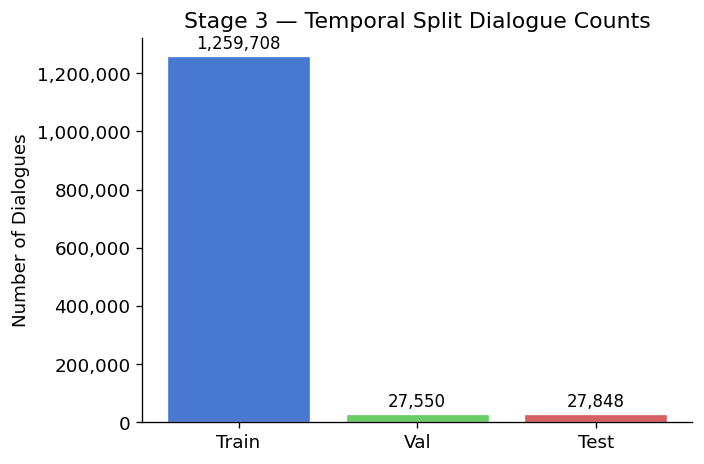

In [10]:
# === SECTION S3.2: Bar chart — train/val/test dialogue counts ===

fig, ax = plt.subplots(figsize=(6, 4))
splits = ['Train', 'Val', 'Test']
counts = [n_train, n_val, n_test]
colors = ['#4878CF', '#6ACC65', '#D65F5F']
bars = ax.bar(splits, counts, color=colors, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            f'{cnt:,}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of Dialogues')
ax.set_title('Stage 3 — Temporal Split Dialogue Counts')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.tight_layout()
_save_fig(fig, 's3_split_counts')
plt.show()


In [11]:
# === NUMERICAL SUMMARY: Train/val/test split counts ===
_total_dlg = n_train + n_val + n_test
t_sp = Table(title='Stage 3 — Temporal Split Dialogue Counts', box=box.SIMPLE_HEAVY)
t_sp.add_column('Split'); t_sp.add_column('Dialogues', justify='right'); t_sp.add_column('%', justify='right')
for _name, _cnt in [('Train', n_train), ('Val', n_val), ('Test', n_test), ('Total', _total_dlg)]:
    _pct = f'{100*_cnt/_total_dlg:.1f}%' if _name != 'Total' else '100.0%'
    t_sp.add_row(_name, f'{_cnt:,}', _pct)
console.print(t_sp)


   Stage 3 — Temporal Split   
       Dialogue Counts        
                              
  Split   Dialogues        %  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Train   1,259,708    95.8%  
  Val        27,550     2.1%  
  Test       27,848     2.1%  
  Total   1,315,106   100.0%

## Stage 4 — Context-Response Pairs

In [12]:
# === SECTION S4.1: stage4_stats.json — pair counts per split ===

if not _require(STAGE4_STATS, 'stage4_stats.json'):
    raise SystemExit('Missing stage4 stats')

s4 = _load_json(STAGE4_STATS)
console.print(Panel(json.dumps(s4, indent=2), title='stage4_stats.json', border_style='blue'))

p_train = s4.get('n_train_pairs', 0)
p_val   = s4.get('n_val_pairs', 0)
p_test  = s4.get('n_test_pairs', 0)
p_total = p_train + p_val + p_test

t = Table(title='Stage 4 — Context-Response Pair Counts', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('Pairs', justify='right')
t.add_column('%', justify='right')
for split, n in [('Train', p_train), ('Val', p_val), ('Test', p_test)]:
    pct = f'{100*n/p_total:.1f}%' if p_total > 0 else 'N/A'
    t.add_row(split, f'{n:,}', pct)
t.add_row('[bold]Total[/bold]', f'[bold]{p_total:,}[/bold]', '[bold]100%[/bold]')
console.print(t)


╭─────────────────────────────────────────────── stage4_stats.json ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": 4,                                                                                                   │
│   "n_train_pairs": 1500000,                                                                                     │
│   "n_val_pairs": 65625,                                                                                         │
│   "n_test_pairs": 66164,                                                                                        │
│   "train_discards": {                                                                                           │
│     "ctx_too_short": 32999,                                                                                     │
│     "resp_too_short": 971910,                                                                                   │
│     "incoherent_pair": 787063,                                                                                  │
│     "resp_too_long": 132588,                                                                                    │
│     "bot_response": 9072,                                                                                       │
│     "echo_pair": 4410,                                                                                          │
│     "diversity_cap": 1730                                                                                       │
│   },                                                                                                            │
│   "val_discards": {                                                                                             │
│     "incoherent_pair": 18692,                                                                                   │
│     "resp_too_short": 18776,                                                                                    │
│     "ctx_too_short": 803,                                                                                       │
│     "bot_response": 264,                                                                                        │
│     "resp_too_long": 3931,                                                                                      │
│     "echo_pair": 109,                                                                                           │
│     "placeholder_only": 1                                                                                       │
│   },                                                                                                            │
│   "test_discards": {                                                                                            │
│     "incoherent_pair": 18939,                                                                                   │
│     "resp_too_short": 18900,                                                                                    │
│     "ctx_too_short": 838,                                                                                       │
│     "resp_too_long": 4236,                                                                                      │
│     "bot_response": 301,                                                                                        │
│     "echo_pair": 103                                                                                            │
│   },                                                                                                            │
│   "elapsed": "5m 32.6s"                                                                                         │
│ }                                                                                                               │
╰───────────────────────────────────────────────────────

 Stage 4 — Context-Response  
         Pair Counts         
╭───────┬───────────┬───────╮
│ Split │     Pairs │     % │
├───────┼───────────┼───────┤
│ Train │ 1,500,000 │ 91.9% │
│ Val   │    65,625 │  4.0% │
│ Test  │    66,164 │  4.1% │
│ Total │ 1,631,789 │  100% │
╰───────┴───────────┴───────╯

In [13]:
# === SECTION S4.2: Load 100 random train pairs; show 5 examples ===

# stage4 pairs are JSON files (list of dicts with 'ctx' and 'resp' as text strings)
if not _require(STAGE4_TRAIN, 'stage4_train_pairs.json'):
    raise SystemExit('Missing stage4 train pairs')

with open(STAGE4_TRAIN, encoding='utf-8') as f:
    raw_train_pairs = json.load(f)

console.print(f'Loaded {len(raw_train_pairs):,} train pairs from stage4_train_pairs.json')

sample_100 = random.sample(raw_train_pairs, min(100, len(raw_train_pairs)))

console.print('[bold]5 Example Pairs (raw text):[/bold]')
for i, pair in enumerate(sample_100[:5], 1):
    ctx_txt  = pair.get('ctx', pair.get('context', ''))
    resp_txt = pair.get('resp', pair.get('response', ''))
    if isinstance(ctx_txt, list):
        ctx_display = ' __eot__ '.join(str(t) for t in ctx_txt)
    else:
        ctx_display = str(ctx_txt)
    console.print(Panel(
        f'[bold cyan]CTX :[/bold cyan] {ctx_display[:300]}\n'
        f'[bold green]RESP:[/bold green] {str(resp_txt)[:200]}',
        title=f'Pair {i}', border_style='blue', padding=(0,1)
    ))


Loaded 1,500,000 train pairs from stage4_train_pairs.json

5 Example Pairs (raw text):

╭──────────────────────────────────────────────────── Pair 1 ─────────────────────────────────────────────────────╮
│ CTX : hi everyone i heard installing ubuntu on a mac would brick it is it true __eot__ why it will not          │
│ RESP: some guy said its due to smc management with linux                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 2 ─────────────────────────────────────────────────────╮
│ CTX : how to get amarok's job id how to get amarok's job id                                                     │
│ RESP: process id or job id pidof amarokapp' for the process id you could type jobs' in bash to see your jobs    │
│ but i doubt that is what you are referring to                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 3 ─────────────────────────────────────────────────────╮
│ CTX : i dont know its all done by dhcp by the modem __eot__ gateway and all __eot__ yup gateway everything      │
│ __eot__ why is the modem giving you different ip addresses for ubuntu then __eot__ because i have to reboot to  │
│ get to ubuntu and it asks for a new ip everytime it reboots __eot__ what is the ip of yo                        │
│ RESP: yup im getting an ip addy                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 4 ─────────────────────────────────────────────────────╮
│ CTX : does that mean the disks are mounted at that point __eot__ i think so if they dont depend on network or   │
│ raid or something __eot__ i am asking because i want to run a fsck for which the disks are not supposed to be   │
│ mounted . i can do it booting in livecd . __eot__ you can only do it using a bootcd or                          │
│ RESP: i doubt that . amphi yeah i am going to use the sysrescuecd anyway . it has something called partimage    │
│ which might come in handy for me                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 5 ─────────────────────────────────────────────────────╮
│ CTX : i installed the ubuntu server and need to do a proper backup of it . either the backup would be at        │
│ another harddrive or in a iso file that i can burn to a cd and restore in a simple way . any ideas so what      │
│ backup __path__ system is ok to use in server without gui __eot__ i have heard good things abo                  │
│ RESP: thanks . i will check them out                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

     Context     
Word-Length Stats
(100-pair sample)
                 
                 
 ━━━━━━━━━━━━━━━ 
  Min      3     
  Max      260   
  Mean     72.7  
  Median   58    
  p95      167

Saved → C:\git\nlp-final-project\notebooks\visualizations\s4_ctx_word_len.png

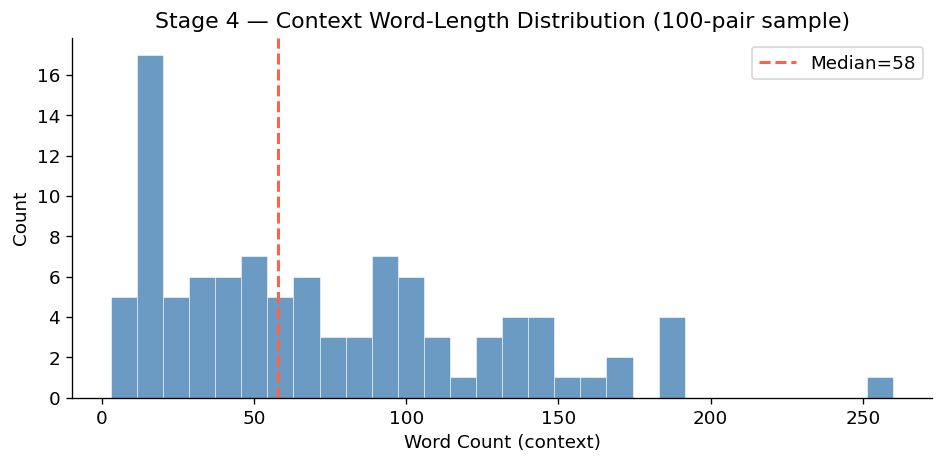

In [14]:
# === SECTION S4.3: Context word-length distribution (from sample) ===

def _word_len(text):
    if isinstance(text, list):
        text = ' '.join(str(t) for t in text)
    return len(str(text).split())

ctx_lens  = [_word_len(p.get('ctx', p.get('context', ''))) for p in sample_100]
resp_lens = [_word_len(p.get('resp', p.get('response', ''))) for p in sample_100]

cl = np.array(ctx_lens)
t = Table(title='Context Word-Length Stats (100-pair sample)', box=box.SIMPLE_HEAVY)
for metric, val in [('Min', cl.min()), ('Max', cl.max()), ('Mean', f'{cl.mean():.1f}'),
                    ('Median', f'{np.median(cl):.0f}'), ('p95', f'{np.percentile(cl,95):.0f}')]:
    t.add_row(metric, str(val))
console.print(t)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cl, bins=30, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(np.median(cl), color='tomato', lw=1.8, ls='--', label=f'Median={np.median(cl):.0f}')
ax.set_xlabel('Word Count (context)')
ax.set_ylabel('Count')
ax.set_title('Stage 4 — Context Word-Length Distribution (100-pair sample)')
ax.legend()
fig.tight_layout()
_save_fig(fig, 's4_ctx_word_len')
plt.show()


In [15]:
# === NUMERICAL SUMMARY: Context word-length percentiles ===
t_cp = Table(title='Context Word-Length Percentile Breakdown (100-pair sample)', box=box.SIMPLE_HEAVY)
t_cp.add_column('Percentile'); t_cp.add_column('Words', justify='right')
for _p in [10, 25, 50, 75, 90, 95, 99]:
    t_cp.add_row(f'p{_p}', f'{np.percentile(cl, _p):.0f}')
console.print(t_cp)
console.print(f'[bold]Band counts:[/bold] '
              f'1–10 words: {int(((cl>=1)&(cl<=10)).sum())}  '
              f'11–30: {int(((cl>=11)&(cl<=30)).sum())}  '
              f'31–80: {int(((cl>=31)&(cl<=80)).sum())}  '
              f'>80: {int((cl>80).sum())}')


 Context Word-Length  
 Percentile Breakdown 
  (100-pair sample)   
                      
  Percentile   Words  
 ━━━━━━━━━━━━━━━━━━━━ 
  p10             15  
  p25             26  
  p50             58  
  p75            104  
  p90            142  
  p95            167  
  p99            192

Band counts: 1–10 words: 5  11–30: 23  31–80: 32  >80: 40

    Response     
Word-Length Stats
(100-pair sample)
                 
                 
 ━━━━━━━━━━━━━━━ 
  Min      5     
  Max      43    
  Mean     14.7  
  Median   12    
  p95      33

Saved → C:\git\nlp-final-project\notebooks\visualizations\s4_resp_word_len.png

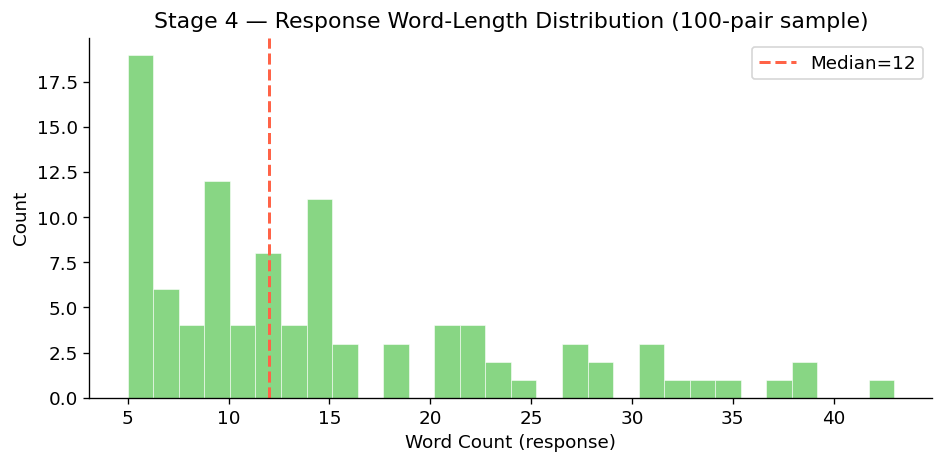

In [16]:
# === SECTION S4.4: Response word-length distribution ===

rl = np.array(resp_lens)
t = Table(title='Response Word-Length Stats (100-pair sample)', box=box.SIMPLE_HEAVY)
for metric, val in [('Min', rl.min()), ('Max', rl.max()), ('Mean', f'{rl.mean():.1f}'),
                    ('Median', f'{np.median(rl):.0f}'), ('p95', f'{np.percentile(rl,95):.0f}')]:
    t.add_row(metric, str(val))
console.print(t)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rl, bins=30, color='#6ACC65', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(np.median(rl), color='tomato', lw=1.8, ls='--', label=f'Median={np.median(rl):.0f}')
ax.set_xlabel('Word Count (response)')
ax.set_ylabel('Count')
ax.set_title('Stage 4 — Response Word-Length Distribution (100-pair sample)')
ax.legend()
fig.tight_layout()
_save_fig(fig, 's4_resp_word_len')
plt.show()


In [17]:
# === NUMERICAL SUMMARY: Response word-length percentiles ===
t_rp = Table(title='Response Word-Length Percentile Breakdown (100-pair sample)', box=box.SIMPLE_HEAVY)
t_rp.add_column('Percentile'); t_rp.add_column('Words', justify='right')
for _p in [10, 25, 50, 75, 90, 95, 99]:
    t_rp.add_row(f'p{_p}', f'{np.percentile(rl, _p):.0f}')
console.print(t_rp)
console.print(f'[bold]Band counts:[/bold] '
              f'1–5 words: {int(((rl>=1)&(rl<=5)).sum())}  '
              f'6–15: {int(((rl>=6)&(rl<=15)).sum())}  '
              f'16–30: {int(((rl>=16)&(rl<=30)).sum())}  '
              f'>30: {int((rl>30).sum())}')


 Response Word-Length 
 Percentile Breakdown 
  (100-pair sample)   
                      
  Percentile   Words  
 ━━━━━━━━━━━━━━━━━━━━ 
  p10              5  
  p25              8  
  p50             12  
  p75             21  
  p90             29  
  p95             33  
  p99             38

Band counts: 1–5 words: 11  6–15: 57  16–30: 22  >30: 10

In [18]:
# === SECTION S4.5: Stage 4.5 domain filter stats (optional) ===

if STAGE4_5_STATS.exists():
    s4_5 = _load_json(STAGE4_5_STATS)
    console.print(Panel(json.dumps(s4_5, indent=2), title='stage4_5_filter_stats.json', border_style='magenta'))

    n_in  = s4_5.get('train', {}).get('total', 0)
    n_out = s4_5.get('train', {}).get('kept', 0)
    n_val_in  = s4_5.get('val', {}).get('total', 0)
    n_val_out = s4_5.get('val', {}).get('kept', 0)
    n_test_in  = s4_5.get('test', {}).get('total', 0)
    n_test_out = s4_5.get('test', {}).get('kept', 0)

    t = Table(title='Stage 4.5 — Domain Filter Stats', box=box.ROUNDED)
    t.add_column('Split', style='cyan')
    t.add_column('Pairs In', justify='right')
    t.add_column('Pairs Out', justify='right')
    t.add_column('Retention %', justify='right', style='green')
    for split, ni, no in [('Train', n_in, n_out), ('Val', n_val_in, n_val_out), ('Test', n_test_in, n_test_out)]:
        ret = f'{100*no/ni:.1f}%' if ni > 0 else 'N/A'
        t.add_row(split, f'{ni:,}', f'{no:,}', ret)
    console.print(t)
else:
    console.print('[yellow]Stage 4.5 filter stats not found — skipping (optional stage)[/yellow]')


╭────────────────────────────────────────── stage4_5_filter_stats.json ───────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": "4.5",                                                                                               │
│   "strategy": "union",                                                                                          │
│   "train": {                                                                                                    │
│     "total": 1500000,                                                                                           │
│     "kept": 1070453,                                                                                            │
│     "pct": 71.36,                                                                                               │
│     "n_cmd": 828286,                                                                                            │
│     "n_question": 509344,                                                                                       │
│     "n_both": 267177                                                                                            │
│   },                                                                                                            │
│   "val": {                                                                                                      │
│     "total": 65625,                                                                                             │
│     "kept": 47791,                                                                                              │
│     "pct": 72.82,                                                                                               │
│     "n_cmd": 37587,                                                                                             │
│     "n_question": 22444,                                                                                        │
│     "n_both": 12240                                                                                             │
│   },                                                                                                            │
│   "test": {                                                                                                     │
│     "total": 66164,                                                                                             │
│     "kept": 47806,                                                                                              │
│     "pct": 72.25,                                                                                               │
│     "n_cmd": 37892,                                                                                             │
│     "n_question": 22151,                                                                                        │
│     "n_both": 12237                                                                                             │
│   },                                                                                                            │
│   "elapsed": "7m 9.4s"                                                                                          │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

        Stage 4.5 — Domain Filter Stats        
╭───────┬───────────┬───────────┬─────────────╮
│ Split │  Pairs In │ Pairs Out │ Retention % │
├───────┼───────────┼───────────┼─────────────┤
│ Train │ 1,500,000 │ 1,070,453 │       71.4% │
│ Val   │    65,625 │    47,791 │       72.8% │
│ Test  │    66,164 │    47,806 │       72.3% │
╰───────┴───────────┴───────────┴─────────────╯

## Summary

In [19]:
# === SECTION SUMMARY: Rich panel summarizing all stage 1-4 stats ===

lines = [
    f'[bold cyan]Stage 1[/bold cyan]  Raw dialogues:  {n_dialogues:,}',
]
if n_kept is not None and n_total is not None:
    lines.append(f'[bold cyan]Stage 2[/bold cyan]  Clean dialogues: {n_kept:,}  (retention {100*n_kept/n_total:.1f}%)')
else:
    lines.append(f'[bold cyan]Stage 2[/bold cyan]  Clean dialogues: {n_kept}')
lines += [
    f'[bold cyan]Stage 3[/bold cyan]  Train: {n_train:,} | Val: {n_val:,} | Test: {n_test:,}',
    f'[bold cyan]Stage 4[/bold cyan]  Pairs — Train: {p_train:,} | Val: {p_val:,} | Test: {p_test:,} | Total: {p_total:,}',
]
if STAGE4_5_STATS.exists():
    lines.append(f'[bold cyan]Stage 4.5[/bold cyan] Domain filter applied (see stats above)')
else:
    lines.append(f'[bold yellow]Stage 4.5[/bold yellow] Not applied (optional)')

console.print(Panel('\n'.join(lines), title='📋 Stages 1–4 Summary', border_style='green'))


╭───────────────────────────────────────────── 📋 Stages 1–4 Summary ─────────────────────────────────────────────╮
│ Stage 1  Raw dialogues:  1,852,868                                                                              │
│ Stage 2  Clean dialogues: 1,315,106  (retention 71.0%)                                                          │
│ Stage 3  Train: 1,259,708 | Val: 27,550 | Test: 27,848                                                          │
│ Stage 4  Pairs — Train: 1,500,000 | Val: 65,625 | Test: 66,164 | Total: 1,631,789                               │
│ Stage 4.5 Domain filter applied (see stats above)                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯